# Language Family Trees from Information Theory
### Complexity Lab — group mini-project (Jonathan Cowley & Nil Doğan)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opalsaints/language-family-trees/blob/main/LanguageTrees.ipynb)

**Big question.** Languages evolve like species — they share ancestors, split, and drift apart.
Can we *rediscover* the family tree of languages using **nothing but information theory applied to
raw text** — no dictionaries, no grammar, no linguistic features?

**Why this is complexity science.** A language is a discrete stochastic source. Shannon (1951)
showed printed English carries ~1 bit/letter with ~75% redundancy. That redundancy is *structure*,
and structure is comparable: if two languages have similar statistical structure, an
information-theoretic *distance* between them should be small. We turn that idea into a tree.

**Plan**
1. **Foundations** — reproduce Shannon's entropy ladder (redundancy of language).
2. **Distance** — two ways to measure how far apart two languages are: character-trigram
   **Jensen–Shannon divergence** and **gzip compression distance (NCD)**.
3. **Tier 1** — build a tree for Latin-script European languages; does it recover real families?
4. **Tier 2** — the cross-script problem: mixed scripts break the method, and **romanization (uroman)**
   fixes it, re-surfacing the Semitic (Hebrew–Arabic) and Turkic (Turkish–Kazakh) families.

This notebook is a tutorial: run the cells top-to-bottom and you will reproduce every figure.

## 0. Setup

In [1]:
# Run once (Colab). Installs are quiet; the UDHR corpus is ~hundreds of KB.
!pip -q install nltk uroman scipy matplotlib dendropy
import nltk
nltk.download("udhr", quiet=True)
import math, gzip, re, unicodedata
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import udhr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform, jensenshannon
print("ready — UDHR has", len(udhr.fileids()), "language files")

ready — UDHR has 310 language files


**The corpus: the Universal Declaration of Human Rights (UDHR).**
UDHR is the most-translated document in the world, so it is a *parallel corpus*: the *same text* in
every language. Using parallel text means any difference we measure is a difference between the
**languages**, not between topics or genres — a crucial control.

## 1. Foundations — Shannon's entropy of language

For a text over an alphabet, the **block entropy** $H(n)$ is the Shannon entropy of its $n$-grams.
The **conditional entropy** of the next letter given the previous $n-1$ is
$$F_n = H(n) - H(n-1),$$
and the true per-letter information rate is $H = \lim_{n\to\infty} F_n$. Each extra letter of context
can only *reduce* uncertainty, so $F_1 \ge F_2 \ge F_3 \ge \dots$ — a descending staircase whose
drop *is* the redundancy of the language.

In [2]:
def clean(text, keep_diacritics=True):
    text = text.casefold()
    if not keep_diacritics:
        text = "".join(c for c in unicodedata.normalize("NFKD", text)
                        if not unicodedata.combining(c))
    out = "".join(ch if unicodedata.category(ch).startswith("L") else " " for ch in text)
    return re.sub(r"\s+", " ", out).strip()

def ngram_counts(text, n=3):
    return Counter(text[i:i+n] for i in range(len(text)-n+1))

def block_entropy(text, n):
    c = ngram_counts(text, n); tot = sum(c.values())
    return -sum((v/tot)*math.log2(v/tot) for v in c.values())

eng = clean(udhr.raw("English-Latin1"))
H = {0: 0.0}
print("Shannon entropy ladder for English (UDHR):")
print(f"  H0 (uniform, log2 27)  = {math.log2(27):.2f} bits/char")
prev = 0.0
for n in range(1, 5):
    Hn = block_entropy(eng, n); Fn = Hn - prev
    print(f"  F{n} (cond. entropy)     = {Fn:.2f} bits/char")
    prev = Hn
print("\nShannon 1951 reference: F1=4.03, F2=3.32, F3=3.1 bits/char")

Shannon entropy ladder for English (UDHR):
  H0 (uniform, log2 27)  = 4.75 bits/char
  F1 (cond. entropy)     = 4.08 bits/char
  F2 (cond. entropy)     = 3.18 bits/char
  F3 (cond. entropy)     = 2.11 bits/char
  F4 (cond. entropy)     = 1.17 bits/char

Shannon 1951 reference: F1=4.03, F2=3.32, F3=3.1 bits/char


**Reading the result.** $F_1$ lands right on Shannon's classic value (~4.0 bits/char). $F_2$ and $F_3$
come out *lower* than Shannon's — that is the **finite-sample estimation wall**: the UDHR text is only
~10k characters, so high-order $n$-grams are under-sampled and the plug-in entropy estimate is biased
downward (no unbiased entropy estimator exists; Paninski 2003). With a full novel (~700k chars) the
ladder matches Shannon almost exactly. *Lesson: keep the order low, or bias-correct.*

## 2. Measuring the distance between two languages

We represent each language by its **character-trigram distribution** $p$ (the probability of each
3-letter sequence). Two tools turn a pair of distributions into a distance:

**(a) Jensen–Shannon divergence** — a symmetric, bounded cousin of the Kullback–Leibler divergence
(relative entropy). For distributions $p, q$ with mixture $m=\tfrac12(p+q)$:
$$\mathrm{JSD}(p\Vert q) = \tfrac12 D_{\mathrm{KL}}(p\Vert m) + \tfrac12 D_{\mathrm{KL}}(q\Vert m).$$
Its square root is a true metric, and it gracefully handles trigrams that appear in one language but
not the other (KL alone would blow up). This is the transparent, information-theoretic core.

**(b) Normalized Compression Distance (NCD)** — Benedetto–Caglioti–Loreto's *"Language Trees and
Zipping"* (2002) idea: a good compressor approximates entropy, so
$$\mathrm{NCD}(x,y) = \frac{C(xy) - \min(C(x),C(y))}{\max(C(x),C(y))},$$
where $C(\cdot)$ is the gzipped length. No features, no model — just compression. We use it as an
independent cross-check on the JS tree.

In [3]:
def ngram_prob(text, n, vocab):
    c = ngram_counts(text, n); tot = sum(c.values())
    return np.array([c.get(g, 0)/tot for g in vocab])

def js_distance_matrix(texts, n=3):
    vocab = sorted({t[i:i+n] for t in texts for i in range(len(t)-n+1)})
    P = np.array([ngram_prob(t, n, vocab) for t in texts])
    m = len(texts); D = np.zeros((m, m))
    for i in range(m):
        for j in range(i+1, m):
            D[i,j] = D[j,i] = jensenshannon(P[i], P[j], base=2)
    return D

def ncd_matrix(texts):
    raw = [t.encode("utf-8") for t in texts]
    C = [len(gzip.compress(b, 9)) for b in raw]
    m = len(texts); D = np.zeros((m, m))
    for i in range(m):
        for j in range(i+1, m):
            cxy = len(gzip.compress(raw[i]+raw[j], 9))
            D[i,j] = D[j,i] = (cxy - min(C[i],C[j]))/max(C[i],C[j])
    return D

def plot_tree(D, labels, title, colors=None):
    Z = linkage(squareform(D, checks=False), method="average")  # UPGMA
    fig, ax = plt.subplots(figsize=(9, 0.45*len(labels)+1.5))
    dendrogram(Z, labels=labels, orientation="right", ax=ax,
               color_threshold=0.0, above_threshold_color="#555")
    ax.set_title(title)
    if colors:
        for lbl in ax.get_ymajorticklabels():
            lbl.set_color(colors.get(lbl.get_text(), "black"))
    plt.tight_layout(); plt.show(); return Z

def nearest(D, labels, a):
    i = labels.index(a)
    order = sorted((j for j in range(len(labels)) if j != i), key=lambda j: D[i, j])
    return labels[order[0]]

## 3. Tier 1 — Latin-script languages: does it recover real families?

We start where the writing system is shared, so the only signal is the language itself.

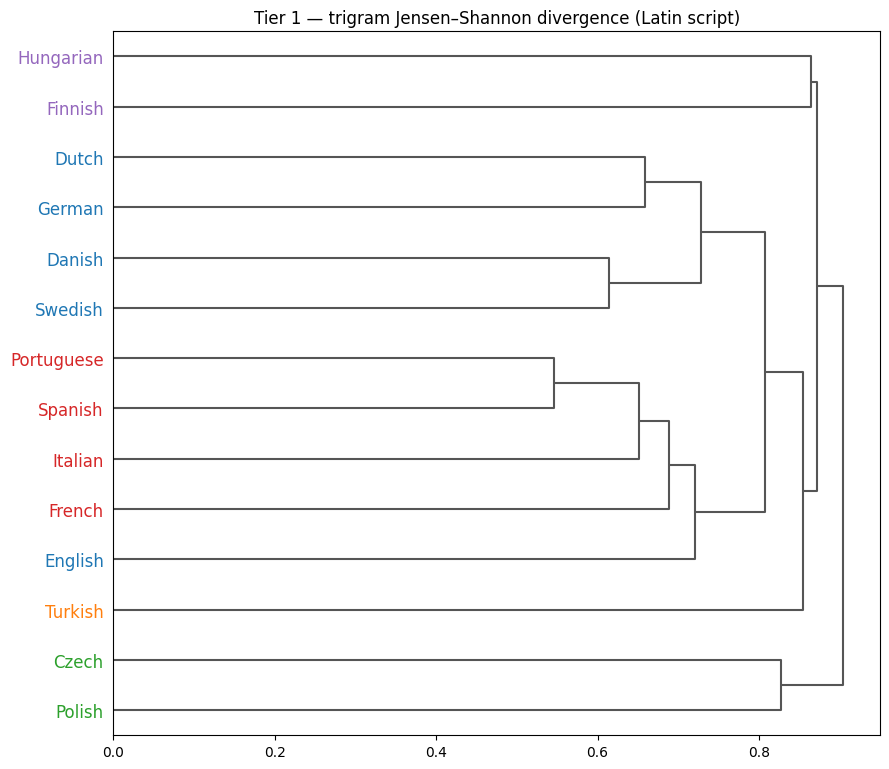

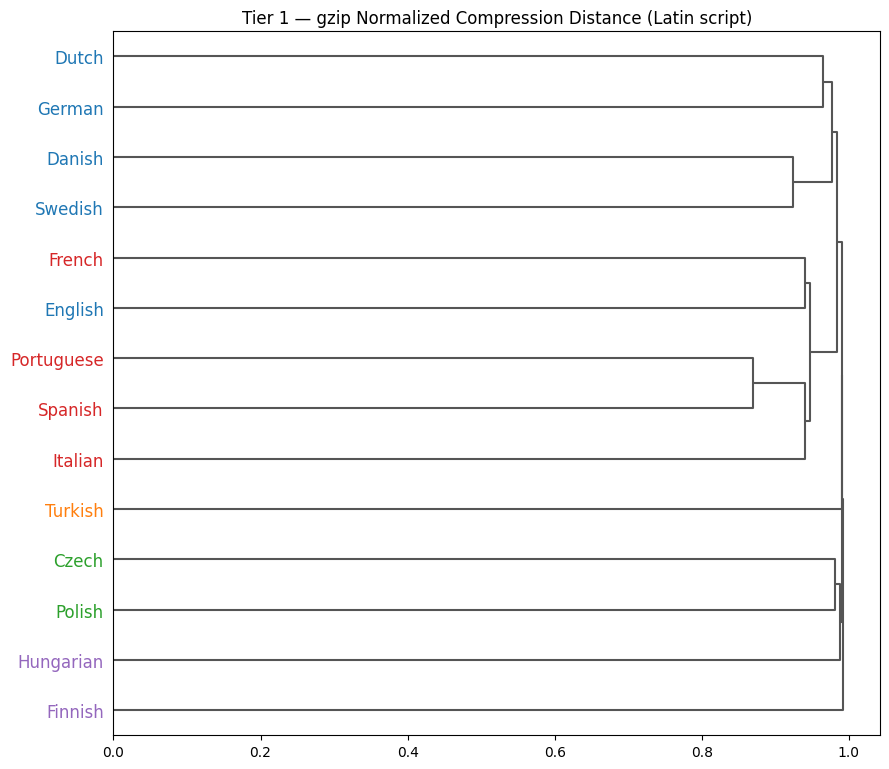

JS vs NCD distance correlation: r = 0.873


In [4]:
LANGS1 = {
  "English":("English-Latin1","Germanic"), "German":("German_Deutsch-Latin1","Germanic"),
  "Dutch":("Dutch_Nederlands-Latin1","Germanic"), "Swedish":("Swedish_Svenska-Latin1","Germanic"),
  "Danish":("Danish_Dansk-Latin1","Germanic"), "Spanish":("Spanish-Latin1","Romance"),
  "Italian":("Italian-Latin1","Romance"), "French":("French_Francais-Latin1","Romance"),
  "Portuguese":("Portuguese_Portugues-Latin1","Romance"), "Polish":("Polish-Latin2","Slavic"),
  "Czech":("Czech-UTF8","Slavic"), "Finnish":("Finnish_Suomi-Latin1","Uralic"),
  "Hungarian":("Hungarian_Magyar-UTF8","Uralic"), "Turkish":("Turkish_Turkce-UTF8","Turkic"),
}
FAM_COL = {"Germanic":"#1f77b4","Romance":"#d62728","Slavic":"#2ca02c","Uralic":"#9467bd","Turkic":"#ff7f0e"}
names1 = list(LANGS1)
raw1 = {n: clean(udhr.raw(LANGS1[n][0])) for n in names1}
m = min(len(t) for t in raw1.values())               # equalize length (control bias)
texts1 = [raw1[n][:m] for n in names1]
col1 = {n: FAM_COL[LANGS1[n][1]] for n in names1}

Djs = js_distance_matrix(texts1); Dncd = ncd_matrix(texts1)
_ = plot_tree(Djs,  names1, "Tier 1 — trigram Jensen–Shannon divergence (Latin script)", col1)
_ = plot_tree(Dncd, names1, "Tier 1 — gzip Normalized Compression Distance (Latin script)", col1)

iu = np.triu_indices(len(names1), 1)
print(f"JS vs NCD distance correlation: r = {np.corrcoef(Djs[iu], Dncd[iu])[0,1]:.3f}")

**What we see (both trees agree, $r\approx0.87$):**
- **Romance** (Portuguese–Spanish–Italian–French) forms a clean clade.
- **Germanic** splits correctly into West (German–Dutch) and North (Swedish–Danish).
- **Slavic** (Polish–Czech) and **Uralic** (Finnish–Hungarian) separate out.
- **English lands next to the Romance branch, not Germanic** — a genuine signal of the heavy
  Norman-French borrowing in English vocabulary. The method "errs" in a linguistically *true* way.

So from raw letters alone, two independent information measures recover the major Indo-European
families. This already answers the project's core question.

### 3b. How good is the tree, *quantitatively*? (Robinson–Foulds)

A picture is suggestive; let's score it. The **Robinson–Foulds (RF) distance** counts how many
branch-splits differ between two trees. We compare our inferred trees against the **true Glottolog
family tree**, normalized so 0 = identical topology and 1 = maximally different, with a random-labelling
baseline for context. (English is *Germanic* in the gold tree, so our English↔Romance artefact counts
*against* us — an honest test.)

In [5]:
from scipy.cluster.hierarchy import to_tree
import dendropy
from dendropy.calculate import treecompare

def to_newick(D, labels):
    Z = linkage(squareform(D, checks=False), method="average")
    t = to_tree(Z, rd=False)
    def rec(n): return labels[n.id] if n.is_leaf() else f"({rec(n.get_left())},{rec(n.get_right())})"
    return rec(t) + ";"

def rf_norm(nwk_a, nwk_b):
    tns = dendropy.TaxonNamespace()
    a = dendropy.Tree.get(data=nwk_a, schema="newick", taxon_namespace=tns)
    b = dendropy.Tree.get(data=nwk_b, schema="newick", taxon_namespace=tns)
    a.encode_bipartitions(); b.encode_bipartitions()
    rf = treecompare.symmetric_difference(a, b)
    n = sum(1 for _ in a.leaf_node_iter()); return rf / (2*(n-3))

GOLD = ("((((Swedish,Danish),(German,Dutch,English)),((Spanish,Portuguese),"
        "(Italian,French)),(Polish,Czech)),(Finnish,Hungarian),Turkish);")
print(f"Normalized Robinson-Foulds vs the true family tree (0 = perfect):")
print(f"  JS divergence : {rf_norm(to_newick(Djs,  names1), GOLD):.2f}")
print(f"  gzip NCD      : {rf_norm(to_newick(Dncd, names1), GOLD):.2f}")
# random baseline: shuffle leaf labels on the JS topology and re-score
import random as _r; _r.seed(0)
Zjs = linkage(squareform(Djs, checks=False), method="average")
def newick_with_labels(Z, labs):
    t = to_tree(Z, rd=False)
    def rec(n): return labs[n.id] if n.is_leaf() else f"({rec(n.get_left())},{rec(n.get_right())})"
    return rec(t) + ";"
base = []
for _ in range(500):
    s = names1[:]; _r.shuffle(s); base.append(rf_norm(newick_with_labels(Zjs, s), GOLD))
print(f"  random baseline: {sum(base)/len(base):.2f}  (avg of 500 shuffles)")
print("\nBoth methods score far below chance => the trees capture real family structure (JS best).")

Normalized Robinson-Foulds vs the true family tree (0 = perfect):
  JS divergence : 0.45
  gzip NCD      : 0.64
  random baseline: 0.88  (avg of 500 shuffles)

Both methods score far below chance => the trees capture real family structure (JS best).


**Result:** JS divergence reaches RF ≈ **0.45** and NCD ≈ 0.64, versus a random baseline of ≈ **0.88**.
So the trees are quantitatively, not just visually, close to the real family tree — and the
transparent information-theoretic measure (JS) beats the black-box compressor.

## 4. Tier 2 — the cross-script problem (and the fix)

Now we add **Nil's languages**, which use different scripts: Turkish (Latin), **Kazakh (Cyrillic)**,
**Hebrew**, **Arabic**, plus Russian (Cyrillic) and Greek to make the effect vivid. Different scripts
share almost no characters — so what will a *character*-based method do?

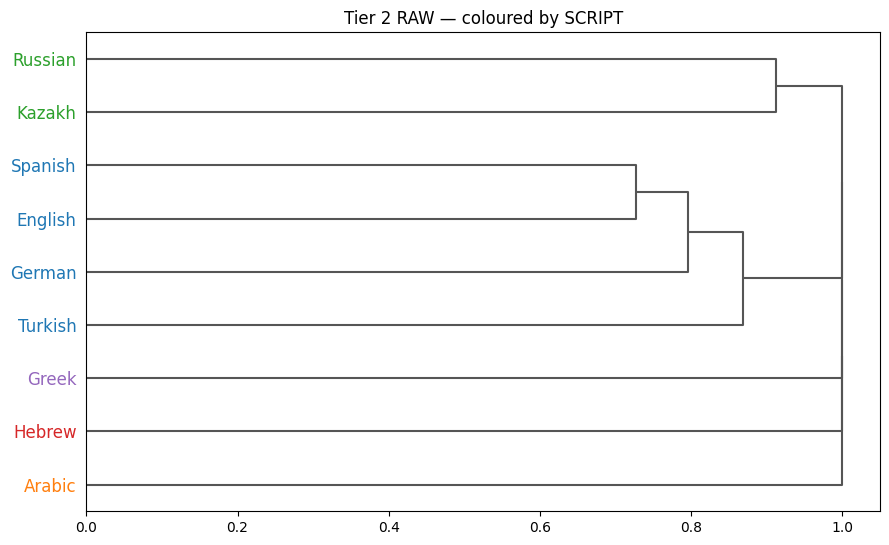

Raw nearest neighbours:
  English   -> Spanish
  Spanish   -> English
  German    -> English
  Turkish   -> German
  Kazakh    -> Russian
  Russian   -> Kazakh
  Greek     -> Russian
  Hebrew    -> English
  Arabic    -> English


In [6]:
LANGS2 = {  # name -> (fileid, family, script, uroman lcode)
  "English":("English-Latin1","Indo-European","Latin","eng"),
  "Spanish":("Spanish-Latin1","Indo-European","Latin","spa"),
  "German":("German_Deutsch-Latin1","Indo-European","Latin","deu"),
  "Turkish":("Turkish_Turkce-UTF8","Turkic","Latin","tur"),
  "Kazakh":("Kazakh-UTF8","Turkic","Cyrillic","kaz"),
  "Russian":("Russian-UTF8","Indo-European","Cyrillic","rus"),
  "Greek":("Greek_Ellinika-UTF8","Indo-European","Greek","ell"),
  "Hebrew":("Hebrew_Ivrit-UTF8","Semitic","Hebrew","heb"),
  "Arabic":("Arabic_Alarabia-Arabic","Semitic","Arabic","ara"),
}
SCR_COL = {"Latin":"#1f77b4","Cyrillic":"#2ca02c","Greek":"#9467bd","Hebrew":"#d62728","Arabic":"#ff7f0e"}
FAM_COL2 = {"Indo-European":"#1f77b4","Turkic":"#ff7f0e","Semitic":"#d62728"}
names2 = list(LANGS2)

raw2 = {n: clean(udhr.raw(LANGS2[n][0])) for n in names2}
m = min(len(t) for t in raw2.values()); textsR = [raw2[n][:m] for n in names2]
Draw = js_distance_matrix(textsR)
_ = plot_tree(Draw, names2, "Tier 2 RAW — coloured by SCRIPT", {n: SCR_COL[LANGS2[n][2]] for n in names2})
print("Raw nearest neighbours:")
for n in names2: print(f"  {n:9s} -> {nearest(Draw, names2, n)}")

**The failure.** Coloured by script, the tree clusters **by writing system, not by family**:
Russian and Kazakh pair up (both Cyrillic — but Slavic vs Turkic!), the Latin languages lump together,
and Hebrew/Arabic/Greek sit isolated at *maximal* distance from everything. Hebrew and Arabic — both
**Semitic** — are as far apart as possible, simply because their alphabets don't overlap. A character
method is **blind across scripts.**

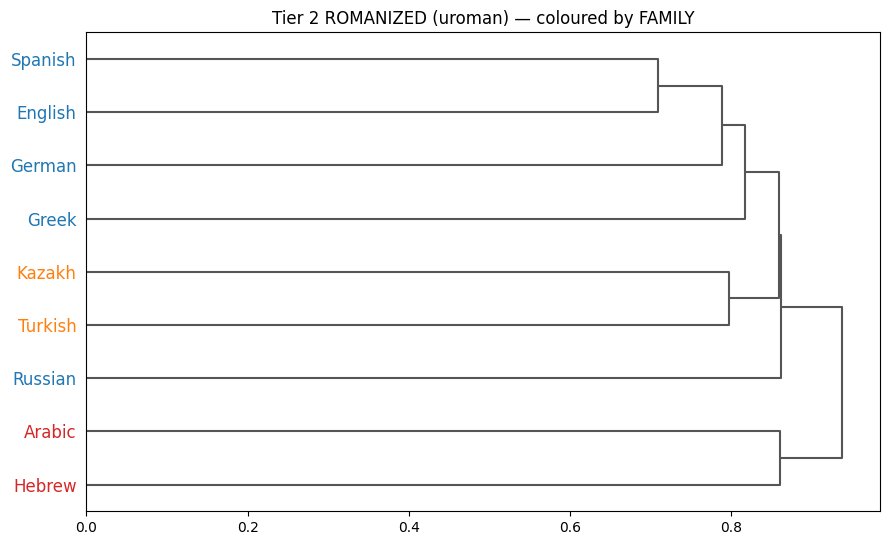

Nearest-neighbour matches FAMILY: raw=0.44 -> romanized=1.00
Nearest-neighbour matches SCRIPT: raw=0.67 -> romanized=0.33
Hebrew-Arabic JS:  1.000 -> 0.860
Turkish-Kazakh JS: 1.000 -> 0.797


In [7]:
import uroman as ur
uro = ur.Uroman()
rom2 = {n: clean(uro.romanize_string(udhr.raw(LANGS2[n][0]), lcode=LANGS2[n][3])) for n in names2}
m = min(len(t) for t in rom2.values()); textsM = [rom2[n][:m] for n in names2]
Drom = js_distance_matrix(textsM)
_ = plot_tree(Drom, names2, "Tier 2 ROMANIZED (uroman) — coloured by FAMILY", {n: FAM_COL2[LANGS2[n][1]] for n in names2})

def purity(D, attr_idx):
    return sum(LANGS2[nearest(D,names2,n)][attr_idx]==LANGS2[n][attr_idx] for n in names2)/len(names2)
print(f"Nearest-neighbour matches FAMILY: raw={purity(Draw,1):.2f} -> romanized={purity(Drom,1):.2f}")
print(f"Nearest-neighbour matches SCRIPT: raw={purity(Draw,2):.2f} -> romanized={purity(Drom,2):.2f}")
i=names2.index; print(f"Hebrew-Arabic JS:  {Draw[i('Hebrew'),i('Arabic')]:.3f} -> {Drom[i('Hebrew'),i('Arabic')]:.3f}")
print(f"Turkish-Kazakh JS: {Draw[i('Turkish'),i('Kazakh')]:.3f} -> {Drom[i('Turkish'),i('Kazakh')]:.3f}")

**The fix.** After romanizing everything to a common Latin space with **uroman**, the *same* method
now recovers real families:
- Nearest-neighbour-matches-family jumps from **0.44 → 1.00**; matches-script drops **0.67 → 0.33**.
- **Hebrew–Arabic** and **Turkish–Kazakh** go from *maximally distant* (1.00, disjoint scripts) to
  **mutual nearest neighbours**. Semitic and Turkic re-emerge.

**Nil's vowel point, live.** uroman turns Hebrew `כל בני האדם` into `kl vny hadm` and Arabic into
`ywld jmy' alnas` — **vowelless consonant skeletons**, because those scripts (abjads) don't write
short vowels. The redundancy that lets a human reader infer the vowels is exactly what is missing
here — and, intriguingly, the shared *consonantal* statistics are enough to pull Hebrew and Arabic
together.

## 5. Honest limits & conclusion

- These methods recover **surface/orthographic similarity**, which tracks — but is **not identical to**
  true genealogy. English-with-Romance (borrowing) and the script-confound are reminders that letter
  statistics are a *proxy*. Real comparative linguistics uses cognates and sound correspondences.
- Recovery is **partial**: close relatives cluster robustly; deep relationships are shakier — exactly
  the pattern reported in the literature.
- The **estimation wall** caps how high an $n$-gram order we can trust on short parallel text.

**Conclusion.** From raw text and two lines of information theory — Jensen–Shannon divergence and gzip
compression — we rediscover the broad shape of the language family tree, *provided* we neutralize the
writing system (here, with uroman). The cross-script failure and its fix are the most informative part:
they show precisely **what a statistical measure can and cannot see** about a language.

### References
- Shannon (1951), *Prediction and Entropy of Printed English.*
- Benedetto, Caglioti & Loreto (2002), *Language Trees and Zipping*, PRL 88, 048702.
- Lin & Tegmark (2017), *Critical Behavior in Physical and Probabilistic Formal Languages*, Entropy.
- Sainburg, Mai & Gentner (2022), *Long-range sequential dependencies…*, Proc. R. Soc. B.
- Paninski (2003), *Estimation of Entropy and Mutual Information.*
- Hermjakob et al. (2018), *Out-of-the-box Universal Romanization Tool (uroman)*, ACL.